In [2]:
!pip install bs4

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import bs4 
from matplotlib import colors
from matplotlib.ticker import PercentFormatter

In [5]:
df = pd.read_csv("steam_all_rev.csv", low_memory=False)
#print(df.head())

In [6]:
import datetime
df2 = df.copy()
#Date Cleaning
#df2['release_date'].dtype
#df2['release_date'] = pd.to_datetime(df2['release_date'])
#df2['release_year']= df2['release_date'].dt.year
#print(df2['release_year'])


#df['release_date'] = pd.to_datetime(df['release_date'])
#print(df['release_date'])
#df['release_date'] = pd.to_datetime(df['release_date'])
#print(df.head())


In [4]:
#Platforms:
df2['platforms'].dtype
df2['platforms'] = df2['platforms'].str.split(';')
df2['windows_sup'] = df2['platforms'].apply(lambda x: 1 if 'windows' in x else 0)
df2['mac_sup'] = df2['platforms'].apply(lambda x: 1 if 'mac' in x else 0)
df2['linux_sup'] = df2['platforms'].apply(lambda x: 1 if 'linux' in x else 0)
print(df2.iloc[:,-20:])

      release_date  english           developer             publisher  \
0       2000-11-01        1               Valve                 Valve   
1       2003-05-01        1               Valve                 Valve   
2       1999-11-01        1    Gearbox Software                 Valve   
3       1998-11-08        1               Valve                 Valve   
4       2004-03-01        1               Valve                 Valve   
...            ...      ...                 ...                   ...   
26863   2019-04-24        1         SHEN JIAWEI           SHEN JIAWEI   
26864   2019-04-23        1      Semyon Maximov      BekkerDev Studio   
26865   2019-04-24        1         EntwicklerX           EntwicklerX   
26866   2019-04-17        1  Yustas Game Studio  Alawar Entertainment   
26867   2019-04-24        1    Adept Studios GD  Alawar Entertainment   

                   platforms  required_age  \
0      [windows, mac, linux]             0   
1      [windows, mac, linux]   

In [49]:
import itertools

#Genres
df2['genres'] = df2['genres'].str.split(';')
unique_gen = np.unique([*itertools.chain.from_iterable(df2['genres'])])
print(unique_gen)

for i in unique_gen:
    df2[i+"_genre"] = df2['genres'].apply(lambda x: 1 if i in x else 0)


TypeError: 'float' object is not iterable

In [6]:
#Categories:
df2['categories'] = df2['categories'].str.split(';')
unique_cat = np.unique([*itertools.chain.from_iterable(df2['categories'])])
print(unique_cat)

for i in unique_cat:
    df2[i+"_cat"] = df2['categories'].apply(lambda x: 1 if i in x else 0)

['Captions available' 'Co-op' 'Commentary available'
 'Cross-Platform Multiplayer' 'Full controller support' 'In-App Purchases'
 'Includes Source SDK' 'Includes level editor' 'Local Co-op'
 'Local Multi-Player' 'MMO' 'Mods' 'Mods (require HL2)' 'Multi-player'
 'Online Co-op' 'Online Multi-Player' 'Partial Controller Support'
 'Shared/Split Screen' 'Single-player' 'Stats' 'Steam Achievements'
 'Steam Cloud' 'Steam Leaderboards' 'Steam Trading Cards'
 'Steam Turn Notifications' 'Steam Workshop' 'SteamVR Collectibles'
 'VR Support' 'Valve Anti-Cheat enabled']


In [7]:
print(df2.iloc[:,-60:])

       mac_sup  linux_sup  Accounting_genre  Action_genre  Adventure_genre  \
0            1          1                 0             1                0   
1            1          1                 0             1                0   
2            1          1                 0             1                0   
3            1          1                 0             1                0   
4            1          1                 0             1                0   
...        ...        ...               ...           ...              ...   
26863        0          0                 0             0                1   
26864        0          0                 0             1                1   
26865        0          0                 0             1                0   
26866        1          0                 0             0                1   
26867        1          0                 0             0                1   

       Animation & Modeling_genre  Audio Production_genre  Casu

In [8]:
#check if game has some external support
support_cols = ['website','support_url', 'support_email']
df2['external_supp'] = df2[support_cols].notna().any(axis=1).astype(int)

In [7]:
#Minimum Requirements:
req_df = df2.iloc[:, 0:6]
req_df.head()
req_df.to_csv('tech_spec.csv')

In [19]:
print(req_df['minimum'].count())
min = pd.DataFrame(req_df['pc_requirements'])
#min.to_csv('min_req.csv')
min
print(min.dtypes)

26864
pc_requirements    object
dtype: object


In [9]:
min_df = min.sample(n=1000)
min_df

,pc_requirements
9590,{'minimum': '<strong>Minimum:</strong><br><ul ...
7962,{'minimum': '<strong>Minimum:</strong><br><ul ...
279,"{'minimum': '<ul class=""bb_ul""><li><strong>OS:..."
2976,{'minimum': '<strong>Minimum:</strong><br><ul ...
3421,{'minimum': '<strong>Minimum:</strong><br><ul ...
...,...
20363,{'minimum': '<strong>Minimum:</strong><br><ul ...
23835,{'minimum': '<strong>Minimum:</strong><br><ul ...
10168,{'minimum': '<strong>Minimum:</strong><br><ul ...
16327,{'minimum': '<strong>Minimum:</strong><br><ul ...


In [20]:
#Parse and take minimum first

import ast
from bs4 import BeautifulSoup

def parse_pc_requirements(raw):
    d = ast.literal_eval(raw)           # string → Python dict
    text = d.get('minimum') or d.get('recommended') or ''
    soup = BeautifulSoup(text, 'html.parser')
    return soup.get_text(separator=' ').strip()


min['cleaned'] = min['pc_requirements'].apply(parse_pc_requirements)



ValueError: malformed node or string: nan

In [48]:
def extract_processor(x):
    match = re.search(r'(\d+\.?\d*\s*(ghz|mhz).{0,20}?processor)', x)
    return match.group(1) if match else None

min_df['processor']= min_df['cleaned'].apply(extract_processor)

In [47]:
min_df

,minimum,cleaned,processor
24594,OS: Windows 7 SP1+ Processor: SSE2 instruction...,24594 os: windows 7 sp1+ processor: sse2 instr...,None
25957,OS: Windows 7 Processor: SSE2 instruction set ...,24594 os: windows 7 sp1+ processor: sse2 instr...,None
20464,OS: Windows 8 Processor: Intel i5 4590- equiva...,24594 os: windows 7 sp1+ processor: sse2 instr...,None
8401,OS: Windows 7 Processor: Intel i3 2 Ghz Memor...,24594 os: windows 7 sp1+ processor: sse2 instr...,None
14673,OS: Windows 7 Memory: 2 GB RAM Storage: 200 MB...,24594 os: windows 7 sp1+ processor: sse2 instr...,None
...,...,...,...
5260,"OS: Windows (XP, Vista, 7, 8) Processor: 1.8 G...",24594 os: windows 7 sp1+ processor: sse2 instr...,None
14270,OS: Windows® XP or higher Processor: Intel Pen...,24594 os: windows 7 sp1+ processor: sse2 instr...,None
12651,OS: Windows 7 Processor: Intel Core i5-750 @ 2...,24594 os: windows 7 sp1+ processor: sse2 instr...,None
11994,Requires a 64-bit processor and operating syst...,24594 os: windows 7 sp1+ processor: sse2 instr...,None


In [10]:
#Removing low-review games:
df2['total_reviews'] = (df2['positive_ratings']+df2['negative_ratings'])

#Set lowest bound to 50 reviews.
low_bound = 4500
df2_trimmed = df2[df2['total_reviews']>=low_bound]

/var/folders/ny/wxw8wfrs4h35q3wg8bt5c4xm0000gn/T/ipykernel_21847/2375011642.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2_trimmed['pos_prop'] = (df2_trimmed['positive_ratings']/df2_trimmed['total_reviews'])


0    0.973888
2    0.947996
3    0.961878
4    0.893871
6    0.965601
Name: pos_prop, dtype: float64


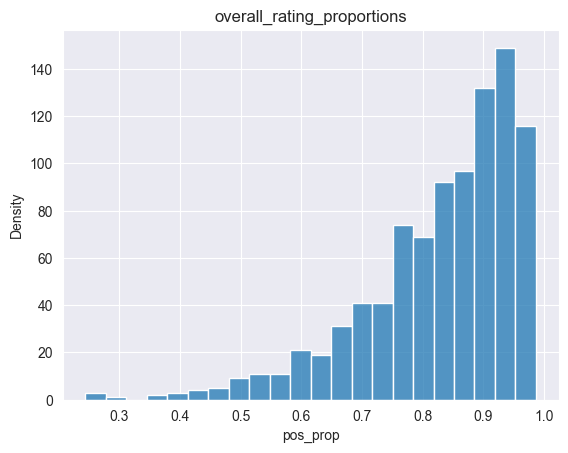

In [11]:
#Add rating proportion
df2_trimmed['pos_prop'] = (df2_trimmed['positive_ratings']/df2_trimmed['total_reviews'])
print(df2_trimmed['pos_prop'].head())

df2_trimmed['pos_prop'].describe()
#Plot:
sns.histplot((df2_trimmed['pos_prop']))

# Adding labels and title
plt.xlabel('pos_prop')
plt.ylabel('Density')
plt.title('overall_rating_proportions')

# Display the plot
plt.show()


In [ ]:
#Removing

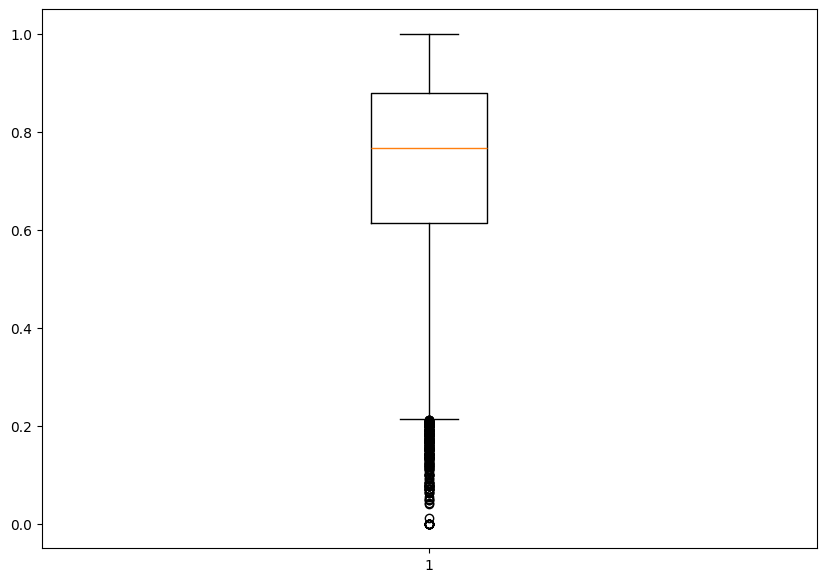

In [14]:
#Boxplot:
pos_prop= df2['pos_prop']
fig = plt.figure(figsize = (10,7))
plt.boxplot(pos_prop)
plt.show()